## Import Libraries


In [ ]:
import tensorflow
from PIL import Image
import glob
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img, save_img, img_to_array
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model,Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout, BatchNormalization,Conv2D, SeparableConv2D, MaxPool2D, LeakyReLU, Activation,GlobalAveragePooling2D

from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau,EarlyStopping
from tensorflow.keras.applications.imagenet_utils import preprocess_input
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
import numpy as np
from tqdm import tqdm
import cv2
import os
import shutil
import itertools
import imutils
from sklearn.model_selection import StratifiedGroupKFold
import random
from tensorflow.keras import layers



## Looking at sample MRI images

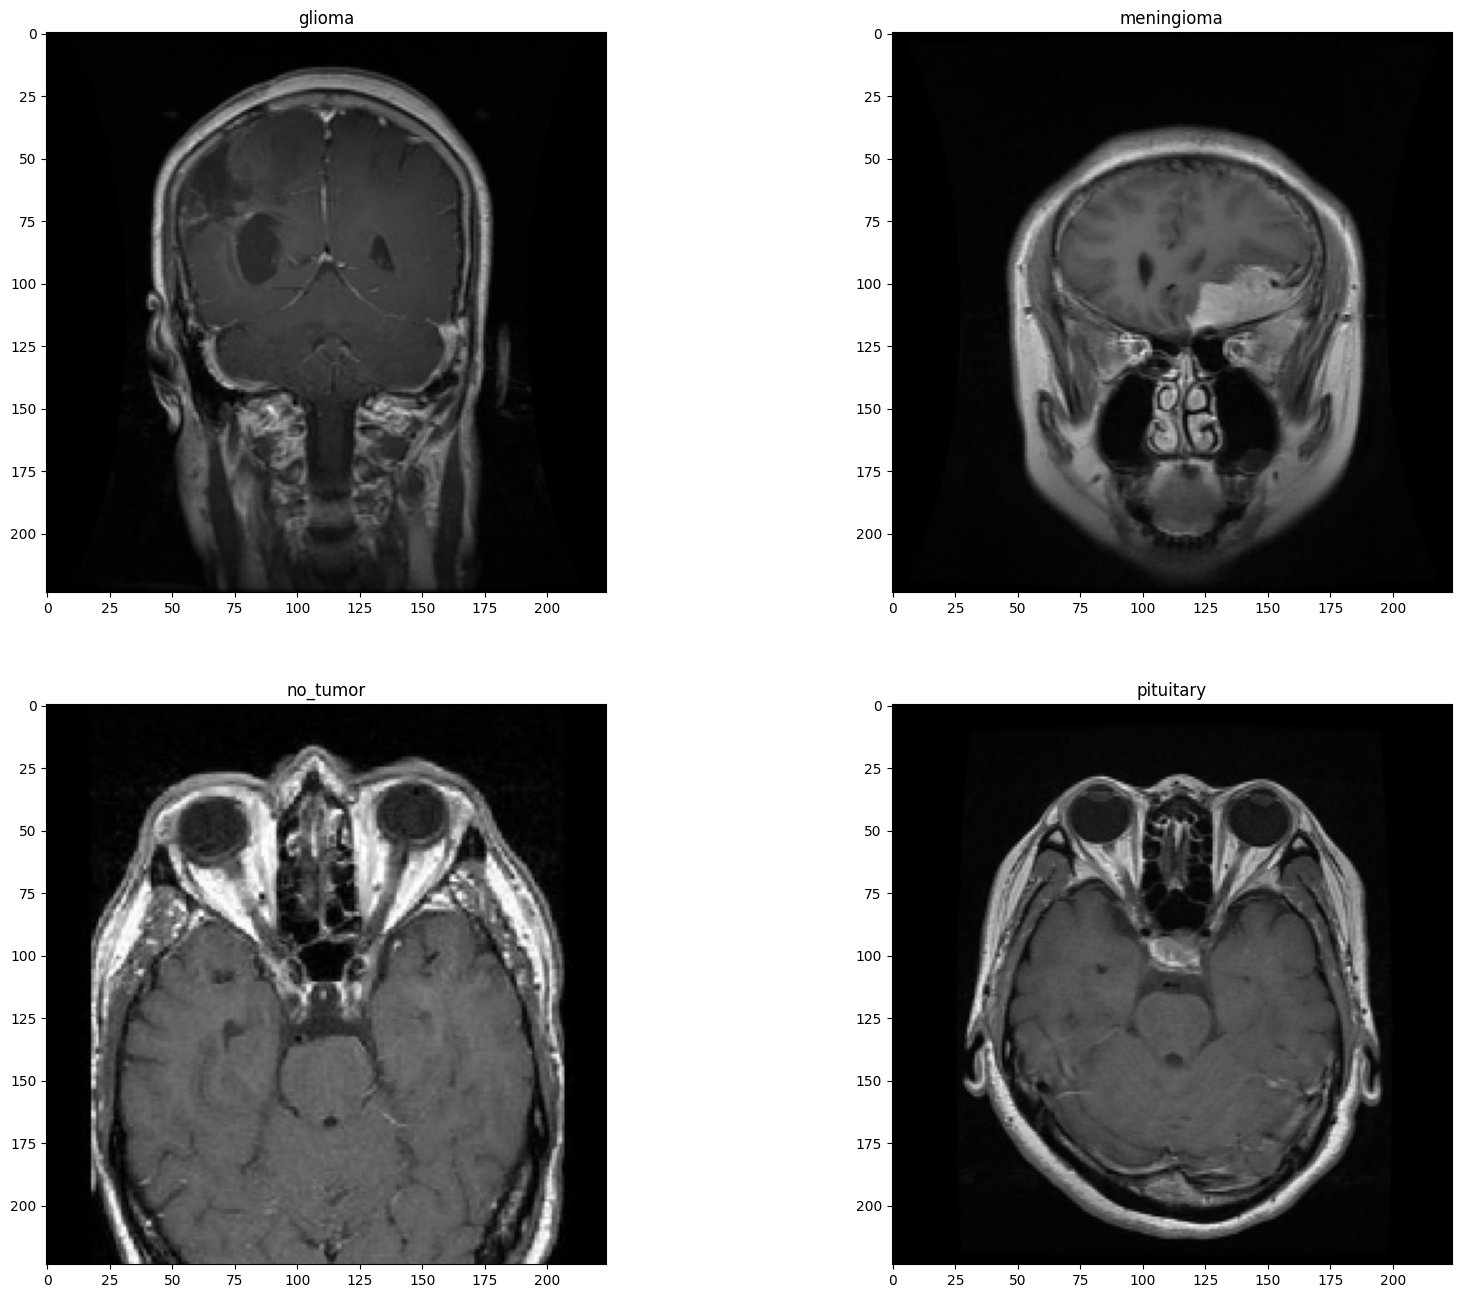

In [ ]:
data_dir = ('Your Training directory') #Input the Training directory
categories = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
plt.figure(figsize=(20, 16))

images_path = ['/glioma/Tr-gl_0010.jpg', '/meningioma/Tr-meTr_0000.jpg', '/no_tumor/Tr-noTr_0000.jpg', '/pituitary/Tr-piTr_0000.jpg'] # 4 pics from each tumor heading

for i in range(4):
    ax = plt.subplot(2, 2, i + 1)
    img = cv2.imread(data_dir + images_path[i])
    img = cv2.resize(img, (224, 224))
    plt.imshow(img)
    plt.title(categories[i])



## Cropping images to make them all the same size

In [ ]:
def crop_img(img):
    """
	Finds the exterior points on the image and crops to that limit
    """
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gray = cv2.GaussianBlur(gray, (3,3),0)
    
    
    thresh = cv2.threshold(gray,45,255, cv2.THRESH_BINARY)[1]
    thresh = cv2.erode(thresh, None, iterations = 2)
    thresh = cv2.dilate(thresh, None, iterations =2)
    
    cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = imutils.grab_contours(cnts)
    c = max(cnts, key = cv2.contourArea)
    
    
    extLeft = tuple(c[c[:, :, 0].argmin()][0])
    extRight = tuple(c[c[:, :, 0].argmax()][0])
    extTop = tuple(c[c[:, :, 1].argmin()][0])
    extBottom = tuple(c[c[:, :, 1].argmax()][0])
    ADD_PIXELS = 0
    new_img = img[extTop[1]-ADD_PIXELS:extBottom[1]+ADD_PIXELS, extLeft[0]-ADD_PIXELS:extRight[0]+ADD_PIXELS].copy()
    
    return new_img



    

In [ ]:
img = cv2.imread('Your test image directory') #Looking at a sample image
img = cv2.resize(
            img,
            dsize = (224,224),
            interpolation = cv2.INTER_CUBIC)
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
gray = cv2.GaussianBlur(gray, (3,3),0)
    
    
thresh = cv2.threshold(gray,45,255, cv2.THRESH_BINARY)[1]
thresh = cv2.erode(thresh, None, iterations = 2)
thresh = cv2.dilate(thresh, None, iterations =2)
    
cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts)
c = max(cnts, key = cv2.contourArea)
    
    
extLeft = tuple(c[c[:, :, 0].argmin()][0])
extRight = tuple(c[c[:, :, 0].argmax()][0])
extTop = tuple(c[c[:, :, 1].argmin()][0])
extBottom = tuple(c[c[:, :, 1].argmax()][0])

img_cnt = cv2.drawContours(img.copy(), [c], -1,(0,255,255),4)

img_pnt = cv2.circle(img_cnt.copy(), extLeft, 8, (0,0,255), -1)
img_pnt = cv2.circle(img_pnt, extRight, 8, (0,0,255), -1)
img_pnt = cv2.circle(img_pnt, extTop, 8, (255,0,0), -1)
img_pnt = cv2.circle(img_pnt, extBottom, 8, (255,255,0), -1)

ADD_PIXELS = 0
new_img = img[extTop[1]-ADD_PIXELS:extBottom[1]+ADD_PIXELS, extLeft[0]-ADD_PIXELS:extRight[0]+ADD_PIXELS].copy()



Text(0.5, 1.0, 'Enlarged Image')

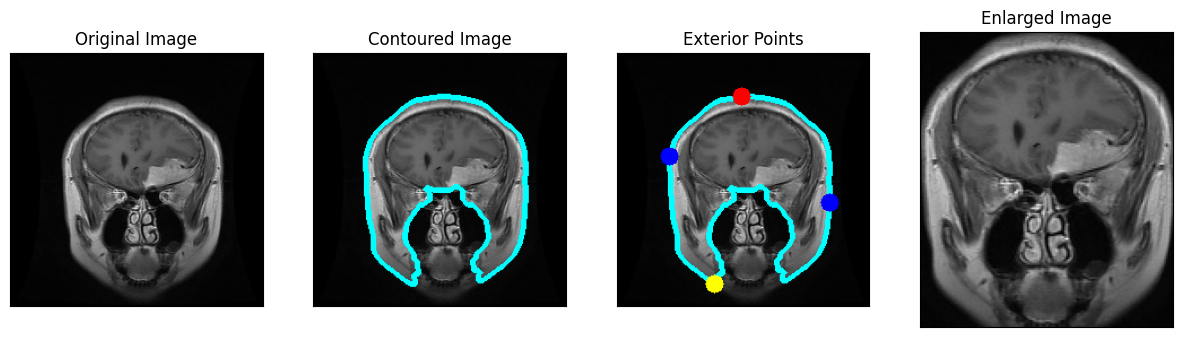

In [6]:
plt.figure(figsize=(15,6))
plt.subplot(141)
plt.imshow(img)
plt.xticks([])
plt.yticks([])
plt.title('Original Image')
plt.subplot(142)
plt.imshow(img_cnt)
plt.xticks([])
plt.yticks([])
plt.title('Contoured Image')
plt.subplot(143)
plt.imshow(img_pnt)
plt.xticks([])
plt.yticks([])
plt.title('Exterior Points')
plt.subplot(144)
plt.imshow(new_img)
plt.xticks([])
plt.yticks([])
plt.title('Enlarged Image')


In [ ]:
if __name__== '__main__':
    training = 'Your Training directory' #Input the Training directory
    testing = 'Your Testing directory' #Input the Testing directory
    training_dir = os.listdir(training)
    testing_dir = os.listdir(testing)
    IMG_SIZE = 256
    
    
    for dir in training_dir:
        save_path = os.path.join('Your cropped Training directory', dir)
        path = os.path.join(training,dir)
        image_dir = os.listdir(path)
        for img in image_dir:
            image = cv2.imread(os.path.join(path,img))
            new_img = crop_img(image)
            new_img = cv2.resize(new_img,(IMG_SIZE,IMG_SIZE))
            if not os.path.exists(save_path):
                os.makedirs(save_path)
            cv2.imwrite(save_path+'/'+img, new_img)
    
    for dir in testing_dir:
        save_path = os.path.join('Your cropped Testing directory', dir)
        path = os.path.join(testing,dir)
        image_dir = os.listdir(path)
        for img in image_dir:
            image = cv2.imread(os.path.join(path,img))
            new_img = crop_img(image)
            new_img = cv2.resize(new_img,(IMG_SIZE,IMG_SIZE))
            if not os.path.exists(save_path):
                os.makedirs(save_path)
            cv2.imwrite(save_path+'/'+img, new_img)
    
        

In [7]:
labels = ['glioma', 'meningioma', 'no_tumor', 'pituitary']

x_train = [] #Image training
y_train = [] #Label training
x_test = [] #Image testing
y_test = [] #Label testing

image_size = 200

for label in labels:
    trainPath = os.path.join('G:/dsr/AAAA/Brain-Tumor-detection-main/cropped/Training', label)
    for file in tqdm(os.listdir(trainPath)):
        image = cv2.imread(os.path.join(trainPath,file), 0) #Gray Images
        image = cv2.bilateralFilter(image ,2,50,50)   #Removes image noise
        image = cv2.applyColorMap(image, cv2.COLORMAP_BONE)    #Colored Image
        image = cv2.resize(image , (image_size, image_size))    #Resize the image to 150*150
        x_train.append(image)
        y_train.append(labels.index(label))
        
    testPath = os.path.join('G:/dsr/AAAA/Brain-Tumor-detection-main/cropped/Testing', label)
    for file in tqdm(os.listdir(testPath)):
        image = cv2.imread(os.path.join(testPath,file), 0) #Gray Images
        image = cv2.bilateralFilter(image ,2,50,50)   #Removes image noise
        image = cv2.applyColorMap(image, cv2.COLORMAP_BONE)    #Colored Image
        image = cv2.resize(image , (image_size, image_size))    #Resize the image to 150*150
        x_test.append(image)
        y_test.append(labels.index(label))
        


100%|██████████| 300/300 [00:05<00:00, 57.07it/s]


In [ ]:
x_train = np.array(x_train) / 255.0
x_test = np.array(x_test) / 255.0

print(x_train.shape)
print(x_test.shape)

(5712, 200, 200, 3)
(1311, 200, 200, 3)


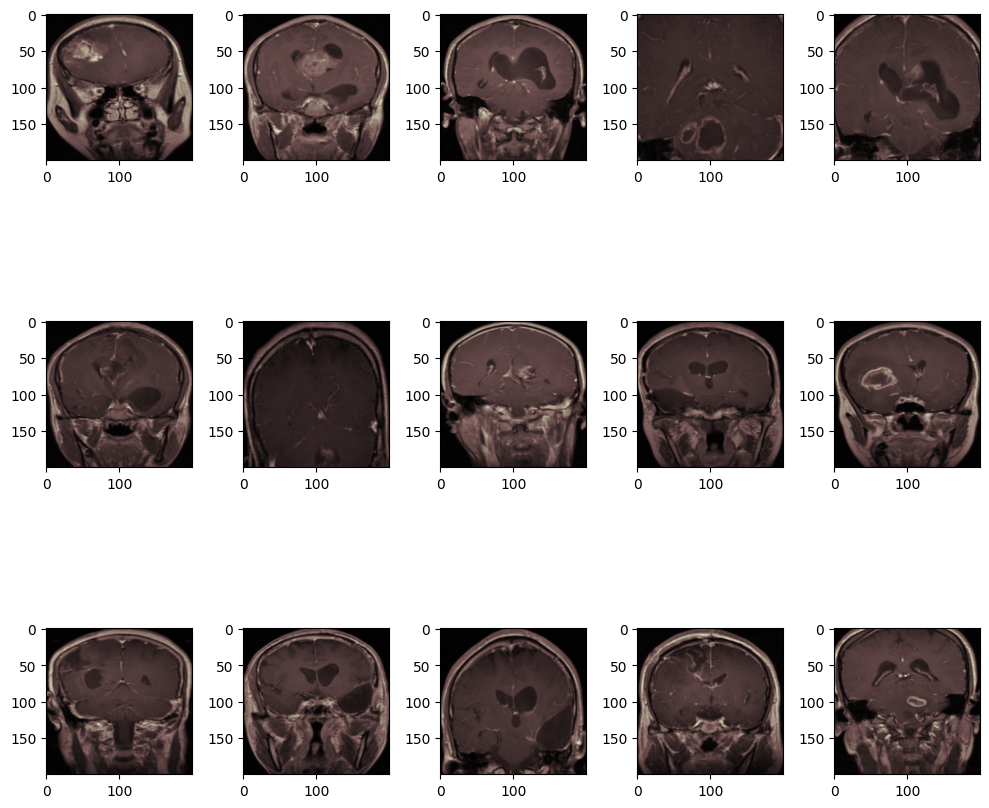

In [9]:
images = [x_train[i] for i in range(15)]
fig , axes = plt.subplots(3,5, figsize = (10,10))
axes = axes.flatten()
for img, ax in zip(images,axes):
    ax.imshow(img)
plt.tight_layout()
plt.show()

In [10]:
x_train, y_train = shuffle(x_train,y_train, random_state=42)

y_train = tensorflow.keras.utils.to_categorical(y_train)
y_test = tensorflow.keras.utils.to_categorical(y_test)

x_train, x_val , y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

print(x_val.shape)

(1143, 200, 200, 3)


In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = r'Your cropped Training directory' 
test_dir  = r'Your cropped Testing directory'

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest",
    validation_split=0.2    
)
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(200, 200),
    batch_size=64,
    class_mode='categorical',
    shuffle=True,
    subset='training'      
)
val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(200, 200),
    batch_size=64,
    class_mode='categorical',
    shuffle=False,
    subset='validation'   
)

test_generator = val_datagen.flow_from_directory(
    test_dir,
    target_size=(200, 200),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)


Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


In [ ]:
# plt.imshow(x[0])
# plt.xticks([])
# plt.yticks([])
# plt.title('Original Image')
# plt.show()

# plt.figure(figsize=(15,6))
# i = 1
# for img in os.listdir('preview_3/'):
#     img = cv2.imread('preview_3/' + img)
#     img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#     plt.subplot(3,7,i)
#     plt.imshow(img)
#     plt.xticks([])
#     plt.yticks([])
#     i += 1
#     if i > 3*7:
#         break
# plt.suptitle('Augemented Images')
# plt.show()

In [ ]:
# datagen.fit(x_train)

In [ ]:
from tensorflow.keras.applications.resnet import ResNet50
IMG_SIZE = (200,200)
conv_base = ResNet50(
    include_top = False,
    input_shape = IMG_SIZE + (3,),
    weights = 'imagenet'
)

for layer in conv_base.layers:
    layer.trainable = True

In [13]:
model = conv_base.output
model = GlobalAveragePooling2D()(model)
model = Dropout(0.4)(model)
model = Dense(4, activation="softmax")(model)
model = Model(inputs= conv_base.input, outputs= model)

In [14]:
adam = Adam(learning_rate=0.0001)
model.compile(optimizer= adam, loss = 'categorical_crossentropy', metrics = ['accuracy'])
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 200, 200, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 206, 206, 3)          0         ['input_1[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 100, 100, 64)         9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 100, 100, 64)         256       ['conv1_conv[0][0]']          
 on)                                                                                          

In [15]:
callbacks = [ModelCheckpoint('.mdl_wts.hdf5', monitor='val_loss', mode='min', verbose=1, save_best_only=True),
             ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2,verbose=1, mode='min', min_lr=0.0000000)]

In [16]:
train_len  = len(x_train)
val_len = len(x_val)
print("--------Training Data Length--------")
print(train_len)

print("--------Validation Data Length--------")
print(val_len)

--------Training Data Length--------
4569
--------Validation Data Length--------
1143


In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=8,
    callbacks=callbacks,
    # steps_per_epoch=len(train_generator),
    # validation_steps=len(val_generator),
)

## Plotting the Loss curves

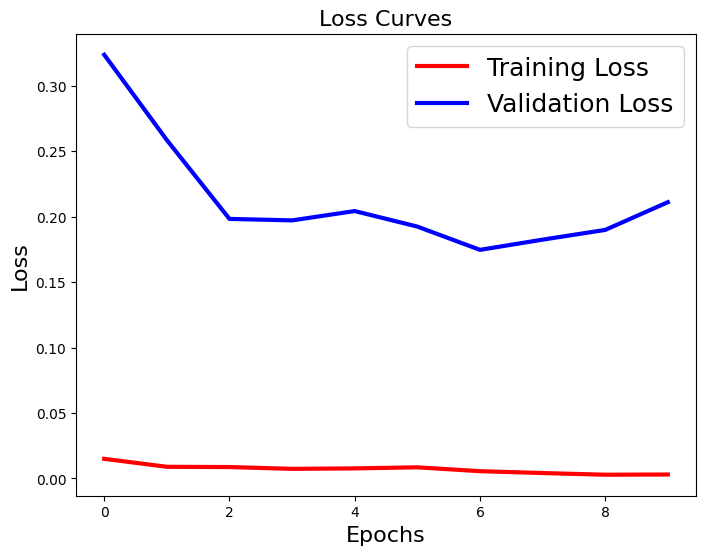

In [23]:
plt.figure(figsize=[8,6])
plt.plot(history.history['loss'], 'r', linewidth = 3.0)
plt.plot(history.history['val_loss'],'b', linewidth = 3.0)
plt.legend(['Training Loss', 'Validation Loss'], fontsize= 18)
plt.xlabel('Epochs', fontsize = 16)
plt.ylabel('Loss', fontsize = 16)
plt.title('Loss Curves', fontsize = 16)
plt.show()

## Plotting the Accuracy curve

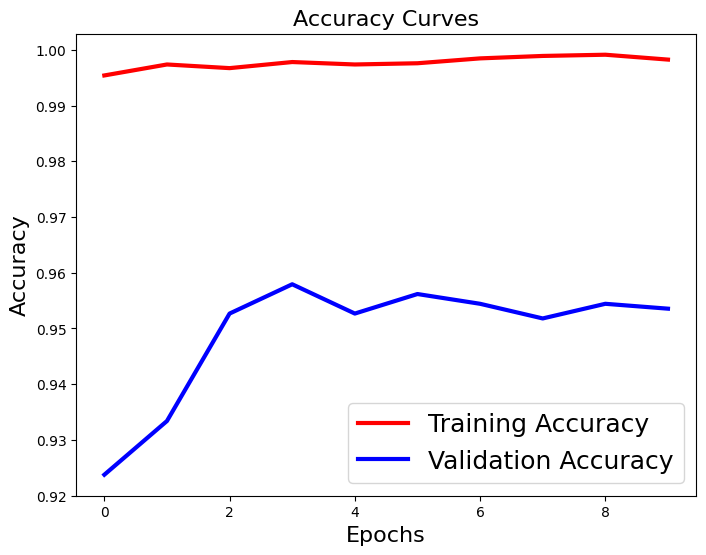

In [24]:
plt.figure(figsize=[8,6])
plt.plot(history.history['accuracy'], 'r', linewidth = 3.0)
plt.plot(history.history['val_accuracy'],'b', linewidth = 3.0)
plt.legend(['Training Accuracy', 'Validation Accuracy'], fontsize= 18)
plt.xlabel('Epochs', fontsize = 16)
plt.ylabel('Accuracy', fontsize = 16)
plt.title('Accuracy Curves', fontsize = 16)
plt.show()

In [ ]:
from tensorflow.keras.models import load_model
import os

model = load_model('')

save_path = os.path.join('', 'Model_Brain')
os.makedirs(save_path, exist_ok=True)

model.save(save_path)

model = load_model(save_path)


Found 1311 images belonging to 4 classes.



21/21 [==============================] - 24s 1s/step - loss: 0.0979 - accuracy: 0.9764
Test loss: 0.0979  -  Test accuracy: 0.9764
21/21 [==============================] - 17s 779ms/step

Classification Report:
              precision    recall  f1-score   support

      glioma       0.97      0.96      0.97       300
  meningioma       0.96      0.97      0.97       306
    no_tumor       0.98      0.98      0.98       405
   pituitary       0.98      0.99      0.99       300

    accuracy                           0.98      1311
   macro avg       0.98      0.98      0.98      1311
weighted avg       0.98      0.98      0.98      1311



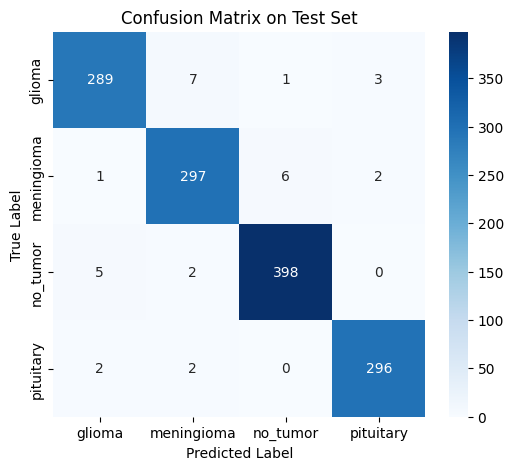

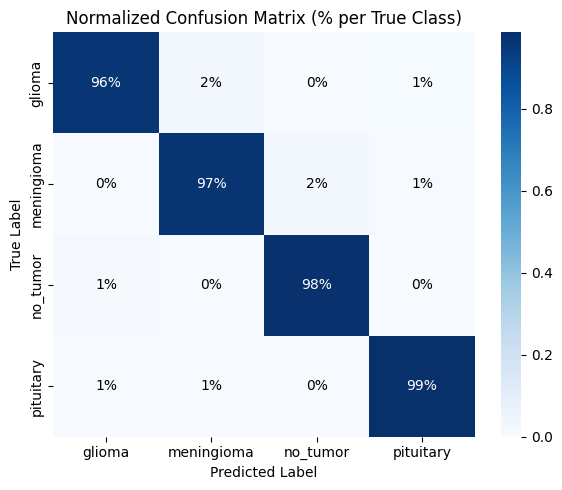

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

test_dir = r'Your cropped Testing directory'  # Input the Testing directory

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_generator = val_datagen.flow_from_directory(
    test_dir,
    target_size=(200, 200),   
    batch_size=64,
    class_mode='categorical',
    shuffle=False              
)

test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"Test loss: {test_loss:.4f}  -  Test accuracy: {test_acc:.4f}")

y_pred_prob = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix on Test Set")
plt.show()


cm_norm = confusion_matrix(y_true, y_pred, normalize='true')

plt.figure(figsize=(6, 5))
ax = sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.0%',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True
)

dark_text = "#ffffff"
light_text = "#2f4470"

for text in ax.texts:
    val = float(text.get_text().strip('%')) / 100.0
    text.set_text(f"{int(round(val * 100))}%")
    text.set_color(dark_text if val > 0.5 else light_text)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix (% per True Class)")
plt.tight_layout()
plt.show()


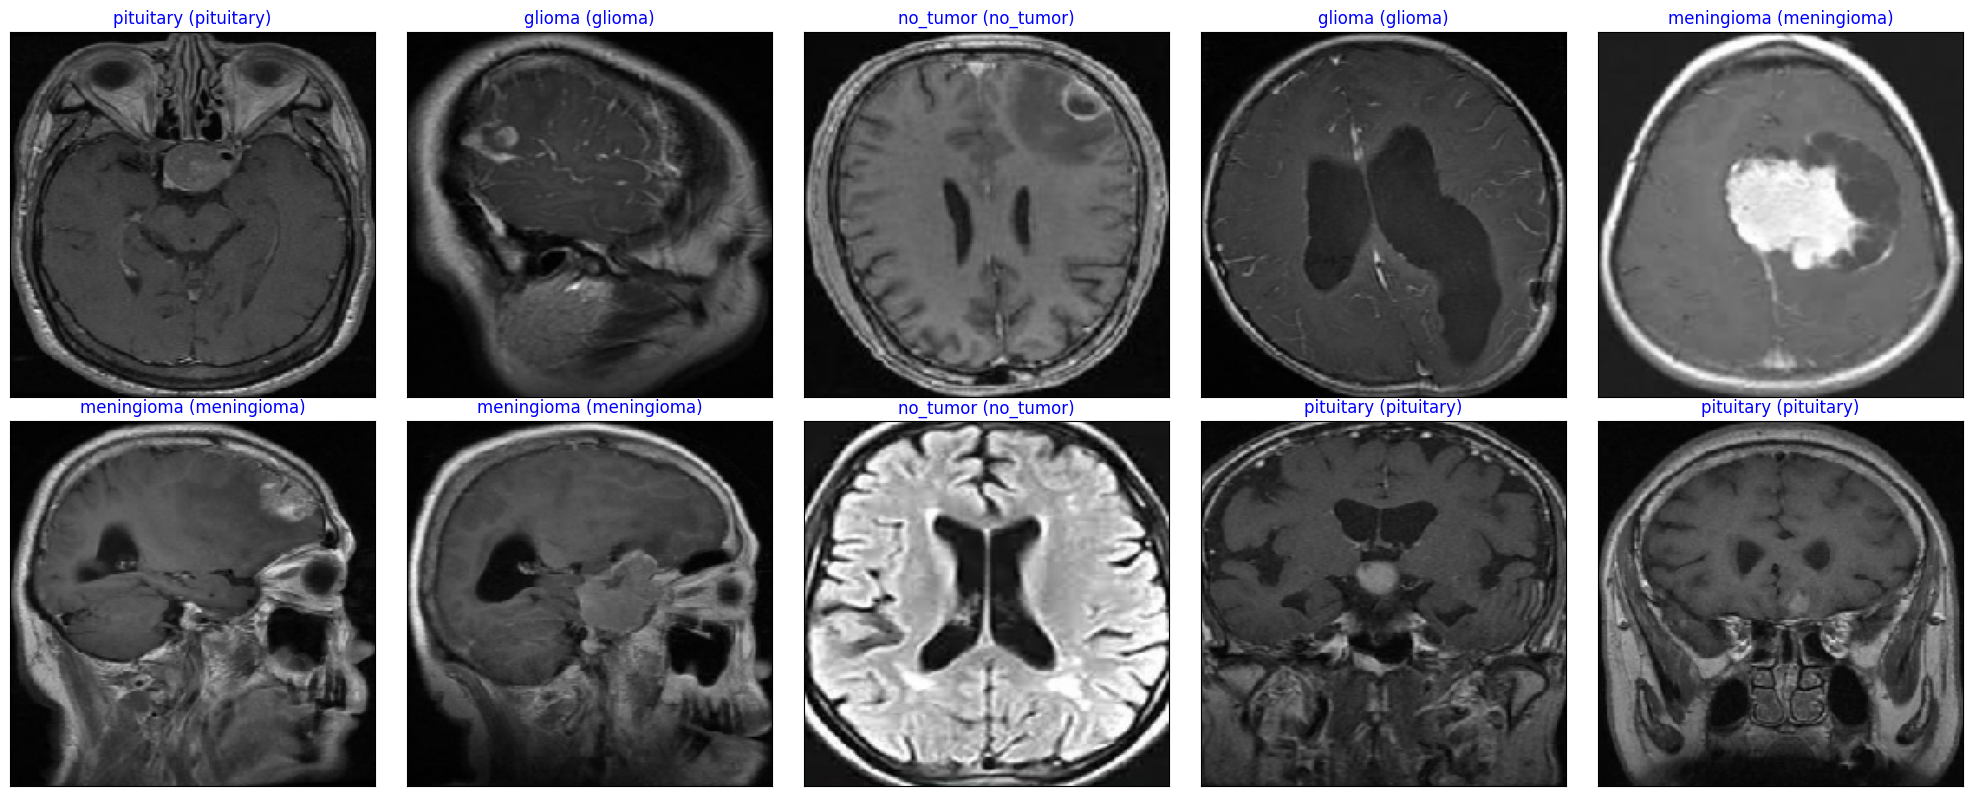

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input

file_paths = test_generator.filepaths
true_labels = test_generator.classes
target_labels = list(test_generator.class_indices.keys())

N = 10
indices = random.sample(range(len(file_paths)), N)

fig = plt.figure(figsize=(20, 8))
for i, idx in enumerate(indices):
    img_path = file_paths[idx]
    img = load_img(img_path, target_size=(200, 200))
    img_arr = img_to_array(img).astype('uint8')
    
    x_input = np.expand_dims(img_arr.copy(), axis=0)
    x_input = preprocess_input(x_input)
    y_hat = model.predict(x_input, verbose=0)
    pred_idx = np.argmax(y_hat, axis=1)[0]
    
    true_idx = true_labels[idx]
    
    ax = fig.add_subplot(2, 5, i+1, xticks=[], yticks=[])
    ax.imshow(img_arr.astype('uint8'))
    color = 'blue' if pred_idx == true_idx else 'orange'
    ax.set_title(f"{target_labels[pred_idx]} ({target_labels[true_idx]})", color=color)

plt.tight_layout()
plt.show()


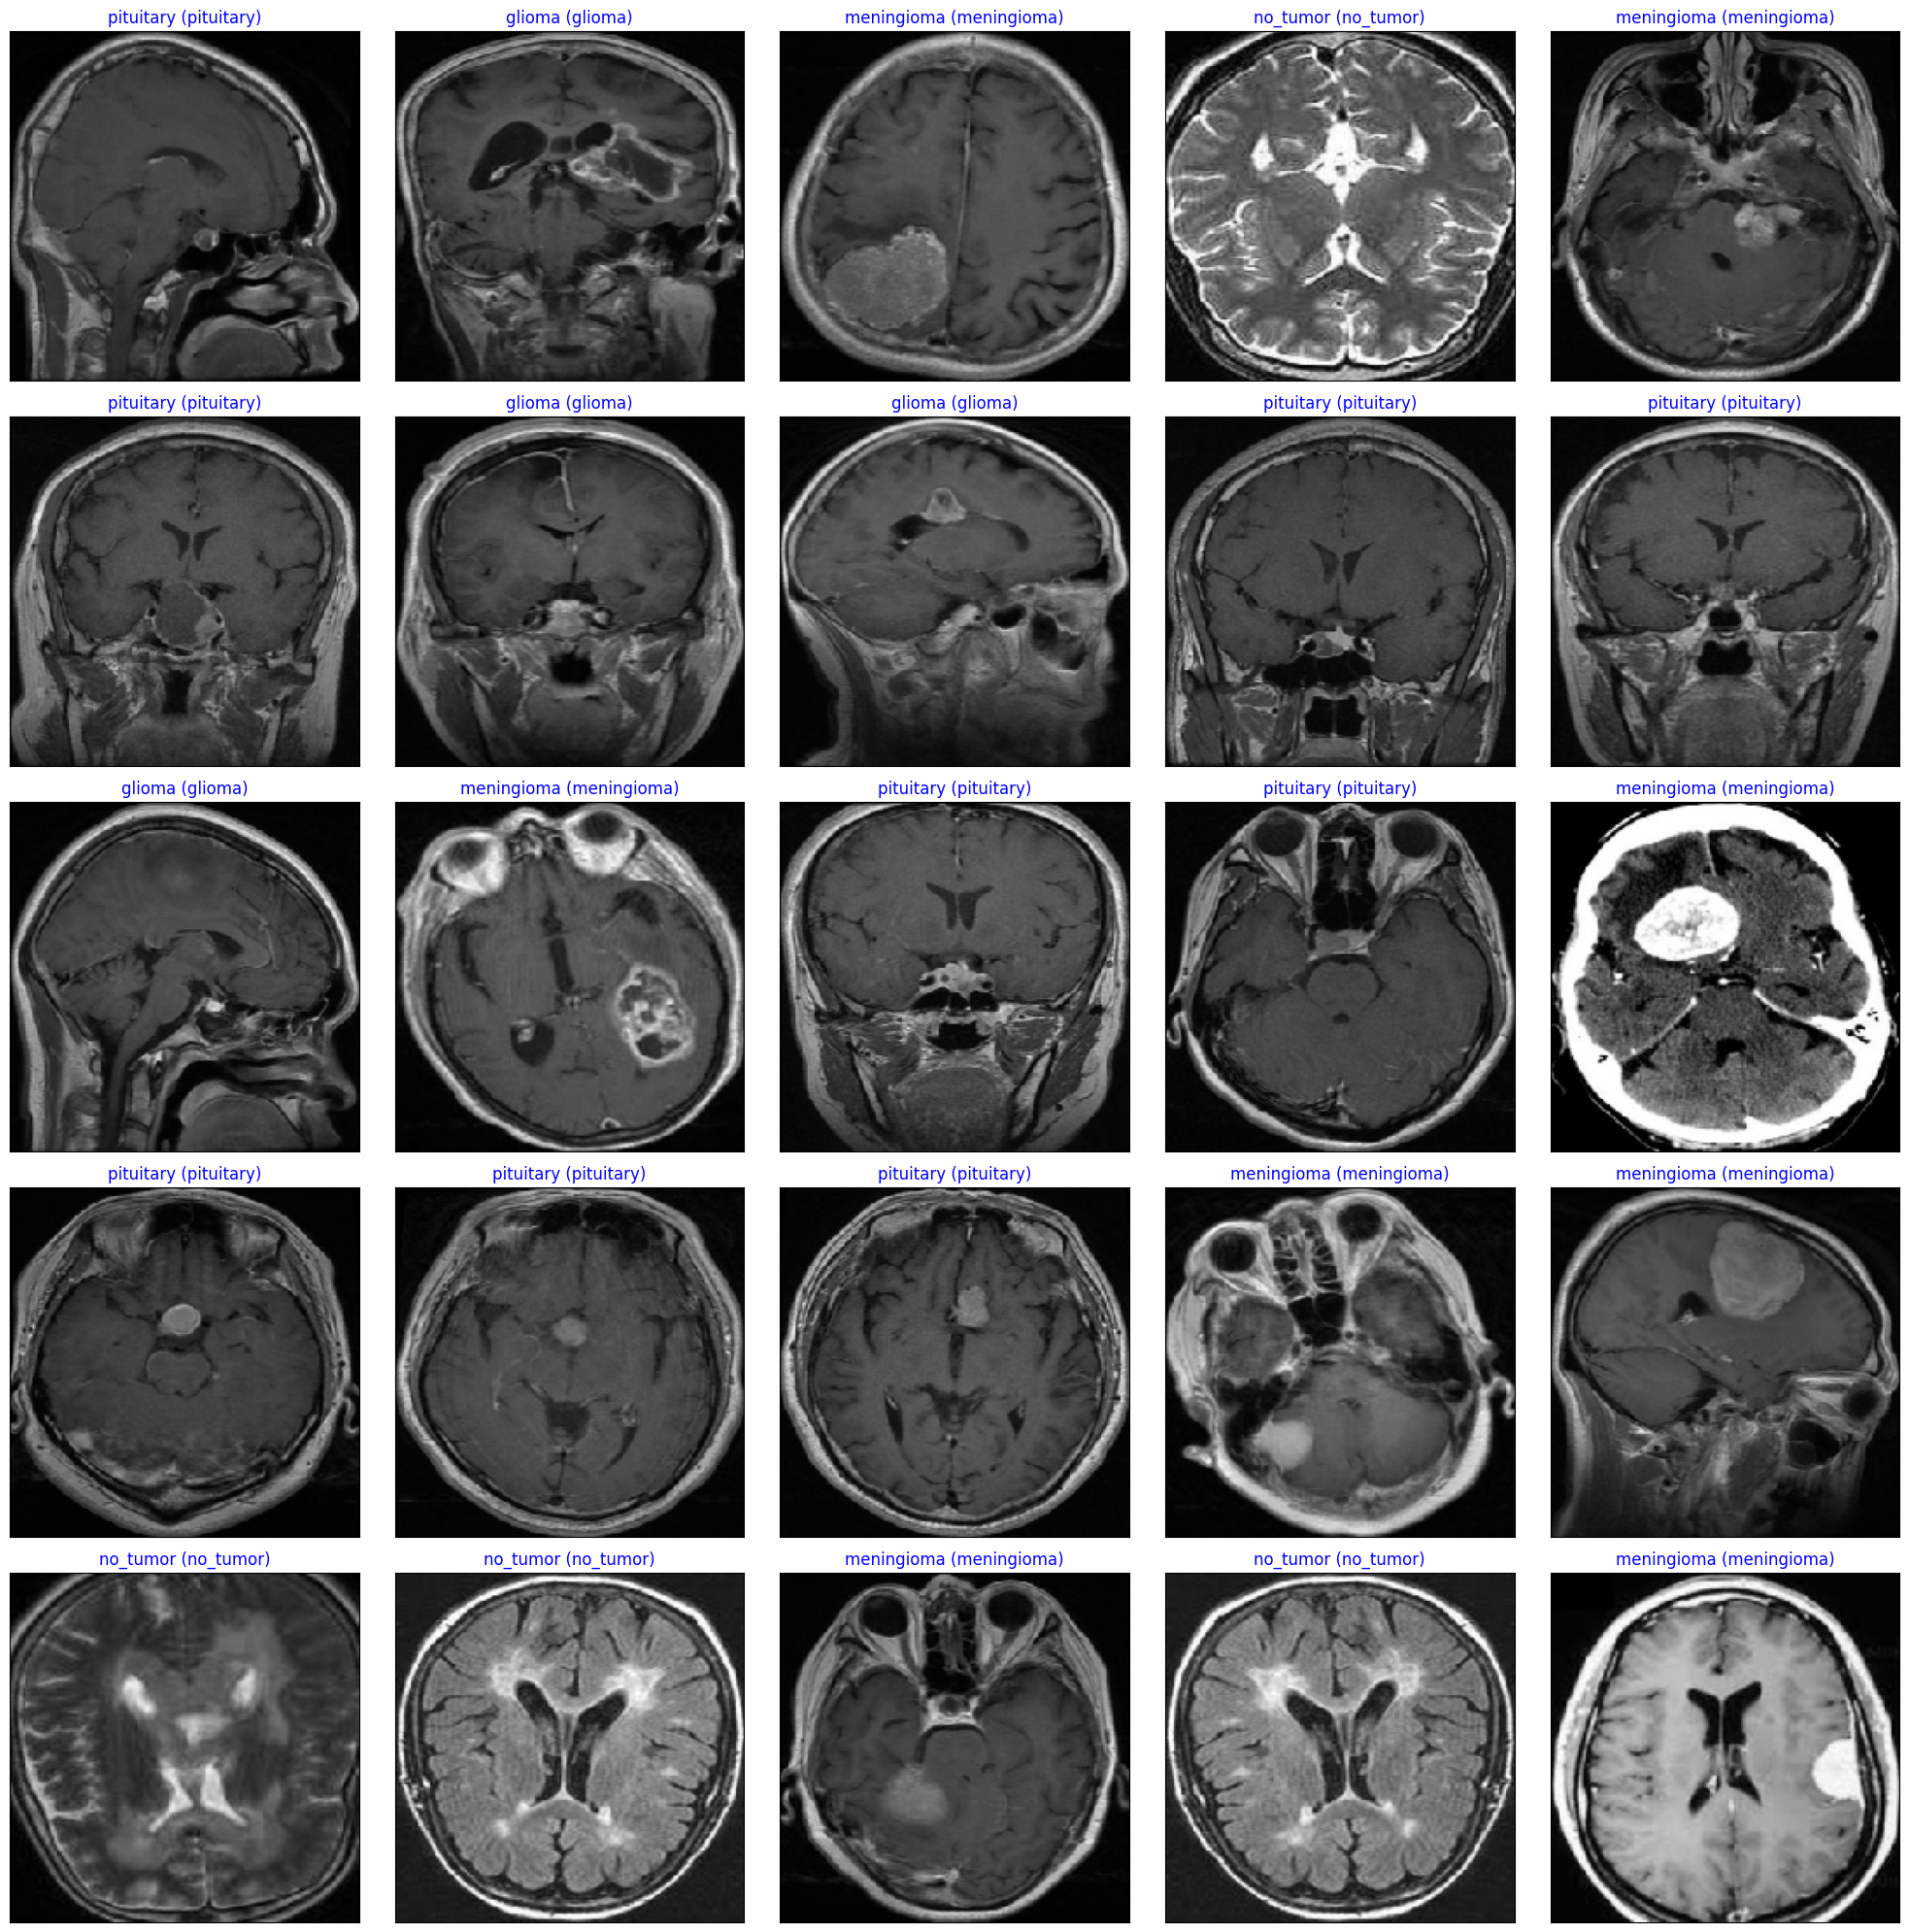

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input

file_paths  = test_generator.filepaths
true_labels = test_generator.classes
target_labels = list(test_generator.class_indices.keys())

indices = random.sample(range(len(file_paths)), 25)

fig = plt.figure(figsize=(20, 20))
for i, idx in enumerate(indices):

    img_path = file_paths[idx]
    img = load_img(img_path, target_size=(200, 200))
    img_arr = img_to_array(img).astype('uint8')

    x_input = np.expand_dims(img_arr.copy(), axis=0)
    x_input = preprocess_input(x_input)
    y_hat = model.predict(x_input, verbose=0)
    pred_idx = np.argmax(y_hat, axis=1)[0]
    true_idx = true_labels[idx]

    ax = fig.add_subplot(5, 5, i+1, xticks=[], yticks=[])
    ax.imshow(img_arr.astype('uint8'))
    color = 'blue' if pred_idx == true_idx else 'orange'
    ax.set_title(f"{target_labels[pred_idx]} ({target_labels[true_idx]})", color=color)

plt.tight_layout()
plt.show()


## Grad-Cam

1/1 [==============================] - 0s 53ms/step


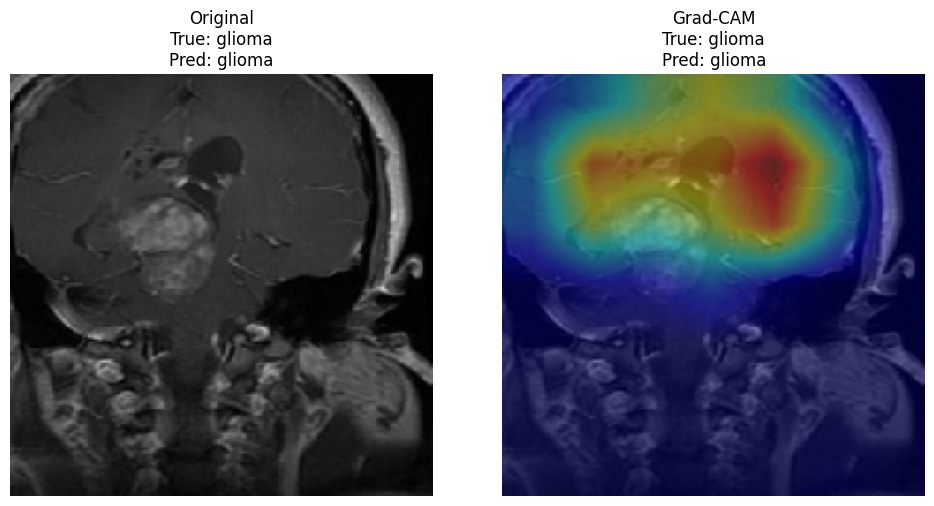

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input

class_indices = test_generator.class_indices
idx2class = {v:k for k,v in class_indices.items()}

idx = np.random.randint(len(test_generator.filepaths))
img_path = test_generator.filepaths[idx]
orig = load_img(img_path, target_size=(200,200))
orig_arr = img_to_array(orig).astype('uint8')

x = preprocess_input(np.expand_dims(orig_arr.copy(), axis=0))
preds = model.predict(x)
pred_idx = np.argmax(preds[0])
true_idx = test_generator.classes[idx]
pred_label = idx2class[pred_idx]
true_label = idx2class[true_idx]

last_conv_layer = model.get_layer("conv5_block3_out")
grad_model = tf.keras.models.Model(
    [model.inputs],
    [last_conv_layer.output, model.output]
)

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(x)
    loss = predictions[:, pred_idx]
grads = tape.gradient(loss, conv_outputs)
pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
heatmap = tf.reduce_sum(conv_outputs[0] * pooled_grads, axis=-1)

heatmap = tf.maximum(heatmap, 0)
heatmap /= tf.reduce_max(heatmap)
heatmap = 1.0 - heatmap
h = heatmap.numpy()
h = cv2.resize(h, (200,200))
h = np.uint8(255 * h)
h = cv2.applyColorMap(h, cv2.COLORMAP_JET)

overlay = cv2.addWeighted(orig_arr, 0.6, h, 0.4, 0)
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(orig_arr)
plt.title(f"Original\nTrue: {true_label}\nPred: {pred_label}")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(overlay)
plt.title(f"Grad-CAM\nTrue: {true_label}\nPred: {pred_label}")
plt.axis("off")

plt.tight_layout()
plt.show()


1/1 [==============================] - 0s 57ms/step


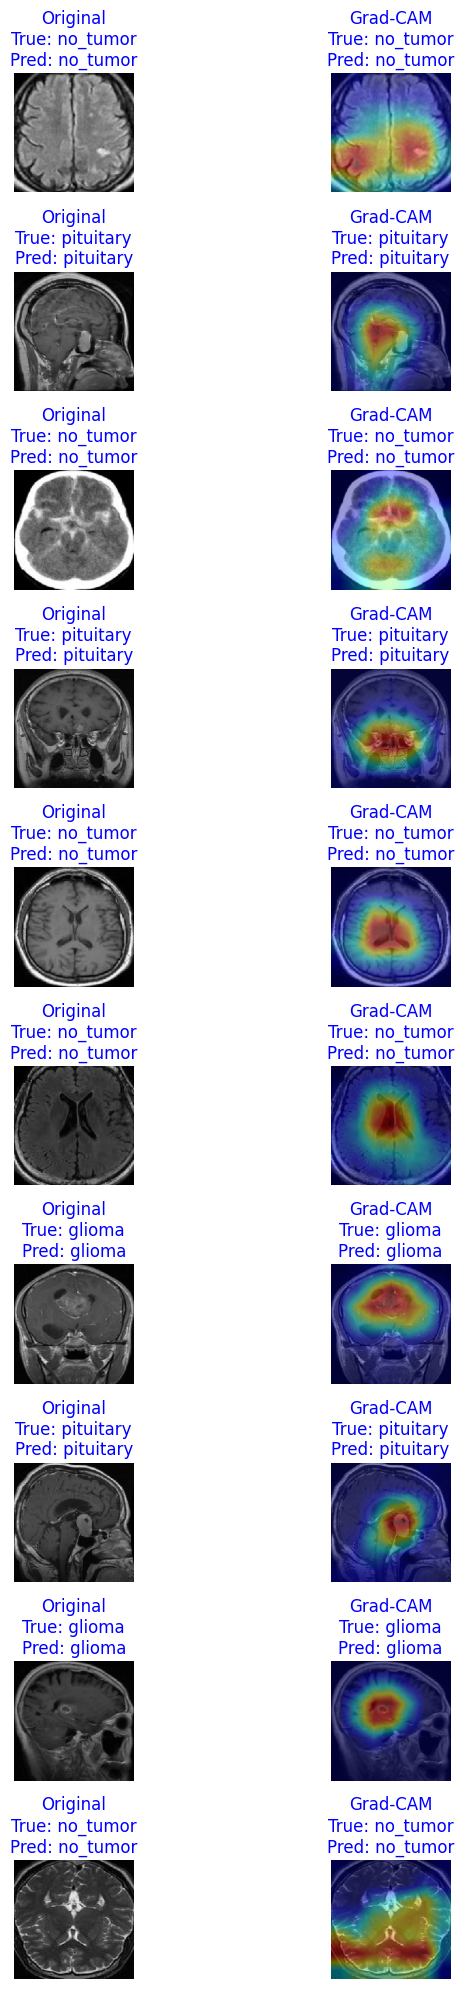

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input

class_indices = test_generator.class_indices
idx2class = {v:k for k,v in class_indices.items()}

def make_gradcam(x, pred_idx):
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(x)
        loss = predictions[:, pred_idx]
    grads = tape.gradient(loss, conv_outputs)
    pooled = tf.reduce_mean(grads, axis=(0,1,2))
    heat = tf.reduce_sum(conv_outputs[0] * pooled, axis=-1)
    heat = tf.maximum(heat, 0)
    heat /= tf.reduce_max(heat)
    heat = 1.0 - heat
    h = heat.numpy()
    h = cv2.resize(h, (200,200))
    h = np.uint8(255 * h)
    return cv2.applyColorMap(h, cv2.COLORMAP_JET)

indices = np.random.choice(len(test_generator.filepaths), 10, replace=False)
fig, axes = plt.subplots(10, 2, figsize=(8, 20))

for i, idx in enumerate(indices):
    img = load_img(test_generator.filepaths[idx], target_size=(200,200))
    arr = img_to_array(img).astype('uint8')
    x = preprocess_input(np.expand_dims(arr.copy(), axis=0))
    preds = model.predict(x)
    pred_idx = np.argmax(preds[0])
    true_idx = test_generator.classes[idx]

    pred_label = idx2class[pred_idx]
    true_label = idx2class[true_idx]
    color = 'blue' if pred_idx == true_idx else 'orange'

    heat = make_gradcam(x, pred_idx)
    overlay = cv2.addWeighted(arr, 0.6, heat, 0.4, 0)

    axes[i,0].imshow(arr)
    axes[i,0].set_title(f"Original\nTrue: {true_label}\nPred: {pred_label}", color=color)
    axes[i,0].axis("off")

    axes[i,1].imshow(overlay)
    axes[i,1].set_title(f"Grad-CAM\nTrue: {true_label}\nPred: {pred_label}", color=color)
    axes[i,1].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
import cv2, itertools, numpy as np, tensorflow as tf
from skimage.metrics import structural_similarity as ssim
from tensorflow.keras.applications.resnet50 import preprocess_input

def apply_small_perturbations(img_uint8):
    angle = np.random.uniform(-5, 5)
    h, w = img_uint8.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
    rot = cv2.warpAffine(img_uint8, M, (w, h), borderMode=cv2.BORDER_REFLECT)
    noise = np.random.normal(0, 5, img_uint8.shape).astype(np.int16)
    perturbed = np.clip(rot.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    return perturbed

def gradcam_gray(arr_uint8, pred_idx):
    x = preprocess_input(np.expand_dims(arr_uint8.copy(), axis=0))
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(x)
        loss = preds[:, pred_idx]
    grads = tape.gradient(loss, conv_out)
    pooled = tf.reduce_mean(grads, axis=(0,1,2))
    heat = tf.reduce_sum(conv_out[0] * pooled, axis=-1)
    heat = tf.maximum(heat, 0) / (tf.reduce_max(heat) + 1e-8)
    heat = 1.0 - heat     
    return cv2.resize(heat.numpy().astype(np.float32), (200, 200))

def ssim_score(h1, h2):
    return ssim(h1, h2, data_range=1.0)


In [ ]:
n_samples   = 50          
stab_scores = []

for _ in range(n_samples):
    idx       = np.random.randint(len(test_generator.filepaths))
    arr_orig  = img_to_array(load_img(test_generator.filepaths[idx], target_size=(200,200))).astype('uint8')
    x_orig    = preprocess_input(np.expand_dims(arr_orig.copy(), axis=0))
    pred_idx  = np.argmax(model.predict(x_orig, verbose=0)[0])

    h0        = gradcam_gray(arr_orig, pred_idx)             
    arr_pert  = apply_small_perturbations(arr_orig)          
    h1        = gradcam_gray(arr_pert, pred_idx)              
    stab_scores.append(ssim_score(h0, h1))

print(f"Grad-CAM Stability (mean SSIM over {n_samples} samples): {np.mean(stab_scores):.4f}")


Grad-CAM Stability (mean SSIM over 50 samples): 0.8516


In [32]:
# Consistency
from collections import defaultdict
np.random.seed(42)

n_per_class = 10          
cons_by_cls = {}
pair_ssim_all = []

for cls_id, cls_name in idx2class.items():
    idxs = np.where(test_generator.classes == cls_id)[0]
    if len(idxs) < 2:           
        continue
    sel = np.random.choice(idxs, min(n_per_class, len(idxs)), replace=False)
    heatmaps = []
    for ix in sel:
        arr = img_to_array(load_img(test_generator.filepaths[ix], target_size=(200,200))).astype('uint8')
        x   = preprocess_input(np.expand_dims(arr.copy(), axis=0))
        pred_idx = np.argmax(model.predict(x, verbose=0)[0])
        heatmaps.append(gradcam_gray(arr, pred_idx))

    pair_scores = [ssim_score(h1, h2) for h1, h2 in itertools.combinations(heatmaps, 2)]
    cons_by_cls[cls_name] = np.mean(pair_scores)
    pair_ssim_all.extend(pair_scores)

print("Grad-CAM Consistency (mean pairwise SSIM)")
for cls_name, score in cons_by_cls.items():
    print(f"  {cls_name:<12}: {score:.4f}")
print(f"Overall mean  : {np.mean(pair_ssim_all):.4f}")


Grad-CAM Consistency (mean pairwise SSIM)
  glioma      : 0.8126
  meningioma  : 0.7655
  no_tumor    : 0.8288
  pituitary   : 0.8175
Overall mean  : 0.8061


## LIME

100%|██████████| 2000/2000 [00:32<00:00, 60.83it/s]


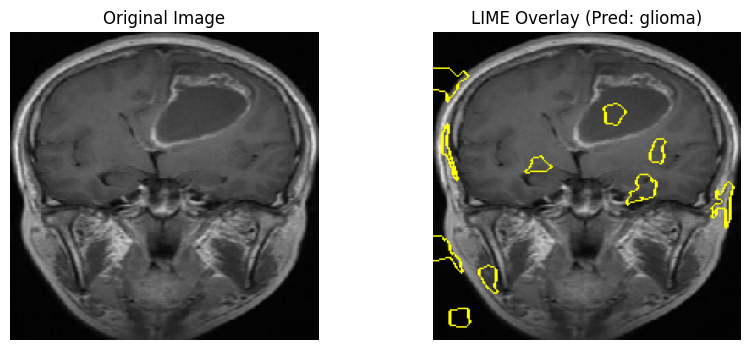

In [ ]:
from lime import lime_image
from skimage.segmentation import slic, mark_boundaries
import matplotlib.pyplot as plt
import numpy as np
import cv2

def segmentation_fn(img):
    return slic(img, n_segments=400, compactness=5, sigma=1)

explainer = lime_image.LimeImageExplainer()

def predict_fn(images_batch):
    x = preprocess_input(images_batch.astype(np.float32))
    return model.predict(x, verbose=0)

def lime_overlay(arr_uint8, num_features=10, positive_only=False, hide_rest=False):
    explanation = explainer.explain_instance(
        image=arr_uint8,
        classifier_fn=predict_fn,
        top_labels=1,
        hide_color=0,
        num_samples=2000,
        batch_size=64,
        segmentation_fn=segmentation_fn
    )
    label = explanation.top_labels[0]
    temp, mask = explanation.get_image_and_mask(
        label,
        positive_only=positive_only,
        num_features=num_features,
        hide_rest=hide_rest
    )
    overlay = mark_boundaries(temp / 255.0, mask)
    return overlay, label

idx = 42
arr = img_to_array(load_img(test_generator.filepaths[idx], target_size=(200,200))).astype(np.uint8)
lime_img, pred_label = lime_overlay(arr, positive_only=True)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(arr)
plt.title(f"Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(lime_img)
plt.title(f"LIME Overlay (Pred: {class_names[pred_label]})")
plt.axis("off")
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
indices = np.random.choice(len(test_generator.filepaths), 9, replace=False)

for i, idx in enumerate(indices):
    img_path = test_generator.filepaths[idx]
    orig = load_img(img_path, target_size=(200,200))
    orig_arr = img_to_array(orig).astype(np.uint8)
    lime_img, lime_label = get_lime_overlay(orig_arr, num_features=10, positive_only=False, hide_rest=False)
    
    ax = axes[i//3, i%3]
    ax.imshow(lime_img)
    ax.set_title(f"{class_names[test_generator.classes[idx]]} → {class_names[lime_label]}")
    ax.axis("off")

plt.tight_layout()
plt.show()


100%|██████████| 2000/2000 [00:33<00:00, 60.37it/s]


LIME Stability (mean SSIM over 5 samples): 0.2632


In [ ]:
import cv2, itertools, numpy as np, tensorflow as tf
from skimage.metrics import structural_similarity as ssim

def apply_small_perturbations(img_uint8):
    angle = np.random.uniform(-5, 5)
    h, w  = img_uint8.shape[:2]
    M     = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
    rot   = cv2.warpAffine(img_uint8, M, (w, h), borderMode=cv2.BORDER_REFLECT)
    noise = np.random.normal(0, 5, img_uint8.shape).astype(np.int16)
    return np.clip(rot.astype(np.int16) + noise, 0, 255).astype(np.uint8)

def lime_gray(arr_uint8):
    exp = explainer.explain_instance(
        image          = arr_uint8,
        classifier_fn  = predict_fn,
        top_labels     = 1,
        hide_color     = 0,
        num_samples    = 2000,
        batch_size     = 64,
        segmentation_fn= segmentation_fn
    )
    label     = exp.top_labels[0]
    segments  = exp.segments              
    weights   = dict(exp.local_exp[label]) 

    heat      = np.zeros_like(segments, dtype=np.float32)
    for seg_id, w in weights.items():
        heat[segments == seg_id] = abs(w)  

  
    heat -= heat.min()
    heat  = heat / (heat.max() + 1e-8)
    return cv2.resize(heat, (200, 200), interpolation=cv2.INTER_LINEAR)

def ssim_score(h1, h2):
    return ssim(h1, h2, data_range=1.0)


In [ ]:
n_samples   = 5
stab_scores = []

for _ in range(n_samples):
    idx = np.random.randint(len(test_generator.filepaths))
    arr_orig = img_to_array(load_img(test_generator.filepaths[idx], target_size=(200,200))).astype(np.uint8)

    h0 = lime_gray(arr_orig)
    arr_pert = apply_small_perturbations(arr_orig)
    h1 = lime_gray(arr_pert)

    stab_scores.append(ssim_score(h0, h1))

print(f"LIME Stability (mean SSIM over {n_samples} samples): {np.mean(stab_scores):.4f}")


100%|██████████| 2000/2000 [00:32<00:00, 61.02it/s]


LIME Stability (mean SSIM over 5 samples): 0.2326


In [ ]:
import itertools
np.random.seed(42)

n_per_class = 6
cons_by_cls = {}
pair_ssim_all = []

for cls_id, cls_name in idx2class.items():
    idxs = np.where(test_generator.classes == cls_id)[0]
    if len(idxs) < 2:
        continue
    sel = np.random.choice(idxs, min(n_per_class, len(idxs)), replace=False)
    heats = []
    for ix in sel:
        arr = img_to_array(load_img(test_generator.filepaths[ix], target_size=(200,200))).astype('uint8')
        heats.append(lime_gray(arr))

    pair_scores = [ssim_score(h1, h2) for h1, h2 in itertools.combinations(heats, 2)]
    cons_by_cls[cls_name] = np.mean(pair_scores)
    pair_ssim_all.extend(pair_scores)

print("LIME Consistency (mean pairwise SSIM)")
for cls_name, score in cons_by_cls.items():
    print(f"  {cls_name:<12}: {score:.4f}")
print(f"Overall mean  : {np.mean(pair_ssim_all):.4f}")


100%|██████████| 2000/2000 [00:31<00:00, 63.88it/s]


LIME Consistency (mean pairwise SSIM)
  glioma      : 0.0791
  meningioma  : 0.1558
  no_tumor    : 0.1652
  pituitary   : 0.1810
Overall mean  : 0.1453


## SHAP

PartitionExplainer explainer: 2it [00:23, 23.07s/it]               


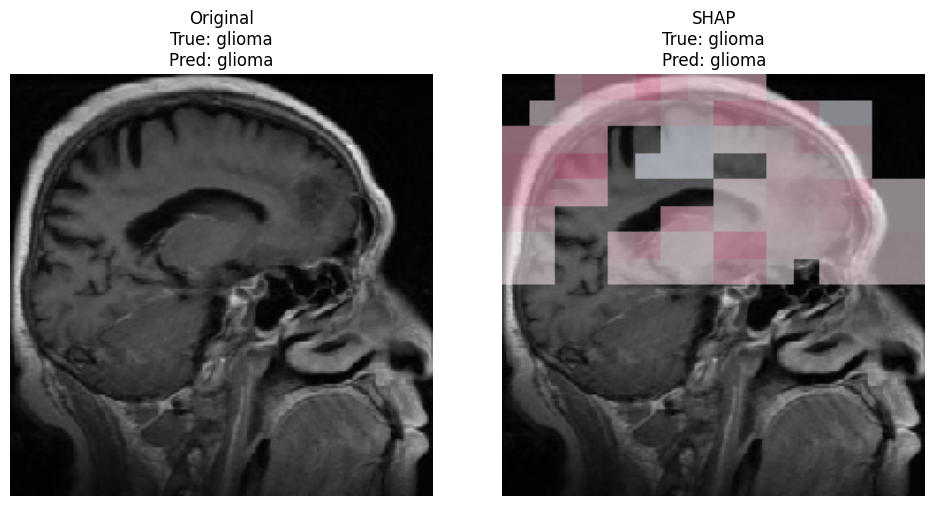

In [ ]:
import numpy as np, shap, cv2, matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input
from skimage.segmentation import slic
from matplotlib.colors import LinearSegmentedColormap

N_SEGMENTS      = 5000  
COMPACTNESS     = 8     
ALPHA_THRESHOLD = 0.10  
ALPHA_LEVEL     = 0.55  
idx        = np.random.randint(len(test_generator.filepaths))
img_path   = test_generator.filepaths[idx]
orig_arr   = img_to_array(load_img(img_path, target_size=(200,200))).astype(np.uint8)
true_idx   = test_generator.classes[idx]
idx2class  = {v:k for k,v in test_generator.class_indices.items()}
true_label = idx2class[true_idx]

def predict_fn(imgs):
    return model.predict(preprocess_input(imgs.copy()), verbose=0)

segments = slic(
    orig_arr,
    n_segments=N_SEGMENTS,
    compactness=COMPACTNESS,
    sigma=1,
    start_label=0,
    enforce_connectivity=True,  
)

masker = shap.maskers.Image("inpaint_telea", orig_arr.shape)
masker.segmentation = segments

explainer = shap.Explainer(predict_fn, masker, output_names=list(idx2class.values()))
x_input   = orig_arr.astype(np.float32)[None, ...]
shap_vals = explainer(x_input, max_evals=800, batch_size=32)  

pred_idx   = int(np.argmax(predict_fn(x_input)[0]))
pred_label = idx2class[pred_idx]
phi        = shap_vals.values[0][..., pred_idx]        

heat = phi.sum(-1)                                   
heat /= (np.percentile(np.abs(heat), 99) + 1e-8)       

alpha_map = (np.abs(heat) >= ALPHA_THRESHOLD).astype(float) * ALPHA_LEVEL  

pink, blue = "#FF8EB0", "#7BA7FF"
cmap = LinearSegmentedColormap.from_list("pinkblue", [blue, "#FFFFFF", pink], N=256)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(orig_arr)
plt.title(f"Original\nTrue: {true_label}\nPred: {pred_label}")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(orig_arr, cv2.COLOR_RGB2GRAY), cmap='gray')
plt.imshow(heat, cmap=cmap, alpha=alpha_map, vmin=-1, vmax=1)
plt.title(f"SHAP\nTrue: {true_label}\nPred: {pred_label}")
plt.axis('off')

plt.tight_layout(); plt.show()


In [ ]:
def shap_gray(arr_uint8):
    segments = slic(arr_uint8, n_segments=5000, compactness=8, sigma=1, start_label=0)
    masker = shap.maskers.Image("inpaint_telea", arr_uint8.shape)
    masker.segmentation = segments

    explainer = shap.Explainer(predict_fn, masker, output_names=list(idx2class.values()))
    x_input = arr_uint8.astype(np.float32)[None, ...]
    shap_vals = explainer(x_input, max_evals=800, batch_size=32)

    pred_idx = int(np.argmax(predict_fn(x_input)[0]))
    phi = shap_vals.values[0][..., pred_idx]
    heat = phi.sum(-1)

    heat /= (np.percentile(np.abs(heat), 99) + 1e-8)
    heat = np.clip((heat + 1) / 2, 0, 1) 
    return heat


In [ ]:
stab_scores = []
n_samples = 5

for _ in range(n_samples):
    idx = np.random.randint(len(test_generator.filepaths))
    arr = img_to_array(load_img(test_generator.filepaths[idx], target_size=(200,200))).astype('uint8')
    arr_pert = apply_small_perturbations(arr)

    h0 = shap_gray(arr)
    h1 = shap_gray(arr_pert)
    stab_scores.append(ssim_score(h0, h1))

print(f"SHAP Stability (mean SSIM over {n_samples} samples): {np.mean(stab_scores):.4f}")


PartitionExplainer explainer: 2it [00:17, 17.47s/it]               
PartitionExplainer explainer: 2it [00:17, 17.88s/it]               
PartitionExplainer explainer: 2it [00:18, 18.35s/it]               
PartitionExplainer explainer: 2it [00:16, 16.55s/it]               
PartitionExplainer explainer: 2it [00:16, 16.11s/it]               
PartitionExplainer explainer: 2it [00:15, 15.82s/it]               
PartitionExplainer explainer: 2it [00:17, 17.32s/it]               
PartitionExplainer explainer: 2it [00:16, 16.90s/it]               
PartitionExplainer explainer: 2it [00:18, 18.49s/it]               
PartitionExplainer explainer: 2it [00:16, 16.10s/it]               

SHAP Stability (mean SSIM over 5 samples): 0.7208


In [ ]:
import itertools
np.random.seed(42)

n_per_class = 6
cons_by_cls = {}
pair_ssim_all = []

for cls_id, cls_name in idx2class.items():
    idxs = np.where(test_generator.classes == cls_id)[0]
    if len(idxs) < 2: continue
    sel = np.random.choice(idxs, min(n_per_class, len(idxs)), replace=False)

    heatmaps = []
    for ix in sel:
        arr = img_to_array(load_img(test_generator.filepaths[ix], target_size=(200,200))).astype('uint8')
        heatmaps.append(shap_gray(arr))

    pair_scores = [ssim_score(h1, h2) for h1, h2 in itertools.combinations(heatmaps, 2)]
    cons_by_cls[cls_name] = np.mean(pair_scores)
    pair_ssim_all.extend(pair_scores)

print("SHAP Consistency (mean pairwise SSIM)")
for cls_name, score in cons_by_cls.items():
    print(f"  {cls_name:<12}: {score:.4f}")
print(f"Overall mean  : {np.mean(pair_ssim_all):.4f}")


PartitionExplainer explainer: 2it [00:18, 18.78s/it]               
PartitionExplainer explainer: 2it [00:16, 16.94s/it]               
PartitionExplainer explainer: 2it [00:17, 17.44s/it]               
PartitionExplainer explainer: 2it [00:18, 18.66s/it]               
PartitionExplainer explainer: 2it [00:17, 17.45s/it]               
PartitionExplainer explainer: 2it [00:18, 18.86s/it]               
PartitionExplainer explainer: 2it [00:16, 16.75s/it]               
PartitionExplainer explainer: 2it [00:16, 16.19s/it]               
PartitionExplainer explainer: 2it [00:17, 17.93s/it]               
PartitionExplainer explainer: 2it [00:17, 17.58s/it]               
PartitionExplainer explainer: 2it [00:17, 17.55s/it]               
PartitionExplainer explainer: 2it [00:17, 17.31s/it]               
PartitionExplainer explainer: 2it [00:17, 17.13s/it]               
PartitionExplainer explainer: 2it [00:18, 18.94s/it]               
PartitionExplainer explainer: 2it [00:17, 17.61s

SHAP Consistency (mean pairwise SSIM)
  glioma      : 0.6890
  meningioma  : 0.7614
  no_tumor    : 0.6819
  pituitary   : 0.6071
Overall mean  : 0.6849
